# Clasificación de Imágenes con Redes Densas (MNIST)

En este notebook aprenderemos a clasificar imágenes de dígitos escritos a mano (0-9) utilizando redes neuronales densas (Multi-Layer Perceptron).

### Objetivos:
1. Comprender la estructura de los datos de imagen (tensores).
2. Normalizar datos de píxeles.
3. Utilizar la capa `Flatten` para adaptar imágenes a capas `Dense`.
4. Evaluar el rendimiento del modelo mediante una matriz de confusión.

In [1]:
# Indicamos que use la versión 2 de Keras, no la 3 (dará error al exportar los modelos)
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

import tensorflow as tf
import tf_keras as keras
from sklearn.metrics import confusion_matrix

print(f"TensorFlow versión: {tf.__version__}")
print(f"Keras versión: {keras.__version__}") # Importante fijarse que sea la 2.19

TensorFlow versión: 2.19.0
Keras versión: 2.19.0


In [2]:
!pip install tensorflowjs

import tensorflowjs as tfjs

## 1. Carga de Datos

Para que este código sea fácil de adaptar, separaremos la **obtención** de los datos de su **procesamiento**.

In [3]:
# OPCIÓN A: Dataset de Keras (MNIST)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Si tuvieras un dataset propio, podrías cargarlo aquí en X_train_raw y X_test_raw
# asegurándote de que tengan la forma (num_muestras, alto, ancho)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)


## 2. Configuración de TensorBoard

In [4]:
root_logdir = os.path.join(os.getcwd(), "logs")

def get_run_logdir(model_name):
    run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    return os.path.join(root_logdir, f"{model_name}_{run_id}")

## 3. Modelo con data augmentation

In [5]:
print("Entrenando Modelo convolucional con data augmentation...")
nombre_modelo = "Modelo_cnn_data_aug"

Entrenando Modelo convolucional con data augmentation...


In [6]:
# Creamos el callback para TensorBoard (irá registrando las salidas de nuestros modelos)
logdir = get_run_logdir(nombre_modelo)
tensorboard_cb = keras.callbacks.TensorBoard(logdir)

In [7]:
# Creamos el callback de EarlyStopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Métrica que queremos vigilar
    patience=5,        # Cuántas épocas esperar sin mejora antes de detenerse
    restore_best_weights=True # ¡Crítico! Nos quedamos con los pesos del punto óptimo
  )

### Preprocesamiento

In [8]:
preprocessing_base = tf.keras.Sequential([
  keras.layers.Resizing(28, 28, crop_to_aspect_ratio=True), # Todas a 28x28 (no sería necesario aquí pero para que lo veais)
  keras.layers.Rescaling(1./255) # De [0, 255] a [0, 1]
])

Visualización para comprobar que funciona:

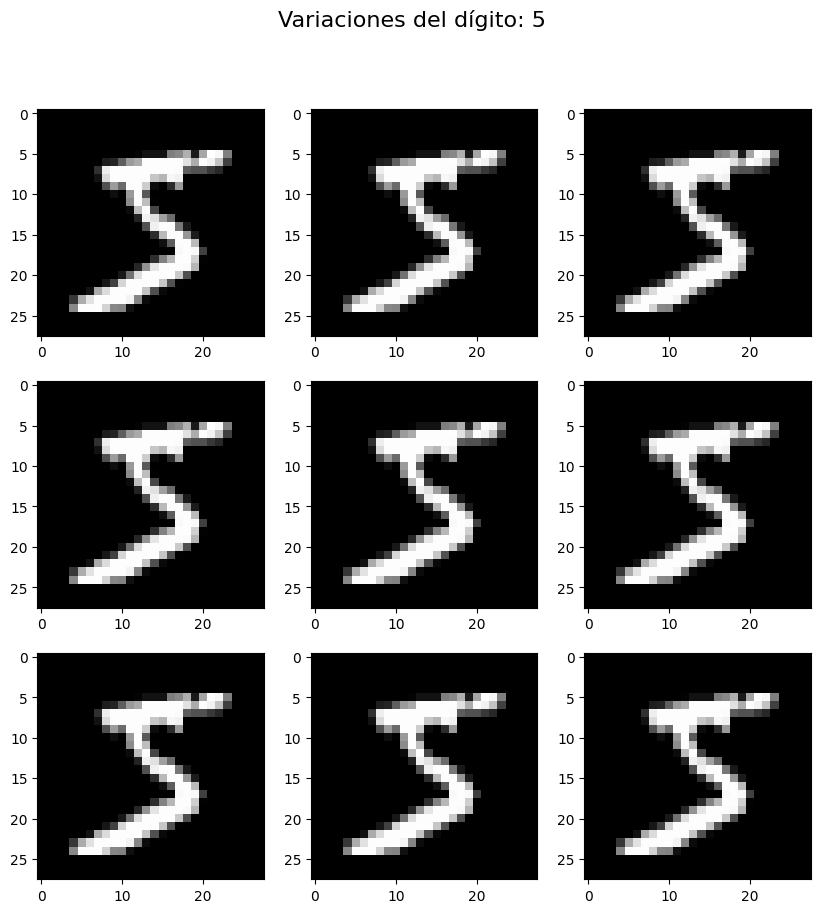

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos una imagen (ej: el primer '5' que encontremos)
image_index = 0
image = X_train[image_index]
label = y_train[image_index]

# Keras espera un batch de imágenes (un conjunto) con dimensión de canal
# Añadimos la dimensión del batch y la dimensión del canal (para imágenes en escala de grises)
img_batch = tf.expand_dims(tf.expand_dims(image, axis=-1), axis=0) # Ahora la forma es (1, 28, 28, 1)

plt.figure(figsize=(10, 10))
plt.suptitle(f"Variaciones del dígito: {label}", fontsize=16)

for i in range(9):
    # ¡IMPORTANTE!: training=True para activar aleatoriedad
    augmented_image = preprocessing_base(img_batch, training=True)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0], cmap='gray') # Corrected: access augmented_image[0] as it's (height, width) directly
    #plt.axis("off")

plt.show()

### Data agumentation

Definimos capas de data augmentation y visualizamos sus resultados

In [10]:
data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.1), # Rotación del 10%
    keras.layers.RandomZoom(0.2),     # Zoom del 10%
    keras.layers.RandomTranslation(0.1, 0.1) # Desplazamiento horizontal/vertical
])

Visualización para comprobar que funciona:

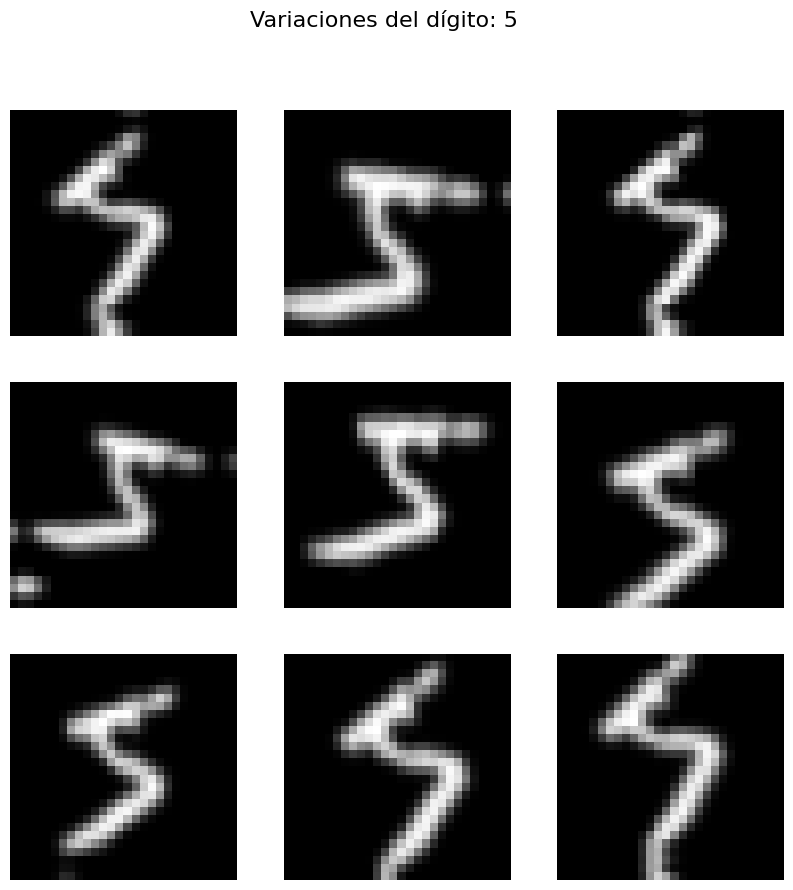

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos una imagen (ej: el primer '5' que encontremos)
image_index = 0
image = X_train[image_index]
label = y_train[image_index]

# Keras espera un batch de imágenes (un conjunto) con dimensión de canal
# Añadimos la dimensión del batch y la dimensión del canal (para imágenes en escala de grises)
img_batch = tf.expand_dims(tf.expand_dims(image, axis=-1), axis=0) # Ahora la forma es (1, 28, 28, 1)

plt.figure(figsize=(10, 10))
plt.suptitle(f"Variaciones del dígito: {label}", fontsize=16)

for i in range(9):
    # ¡IMPORTANTE!: training=True para activar aleatoriedad
    augmented_image = data_augmentation(img_batch, training=True)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0], cmap='gray') # Corrected: access augmented_image[0] as it's (height, width) directly
    plt.axis("off")

plt.show()

In [12]:
model_cnn_data_aug = keras.Sequential([
    preprocessing_base, # Capa preprocesamiento
    data_augmentation, # Capa data augmentation

    keras.layers.Conv2D(32, (3, 3), activation='relu'), # No hay que especificar el input_shape
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(), # Aplanamos los resultados de convolución
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax') # Output: 10 clases
], name=nombre_modelo)

model_cnn_data_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Construir el modelo explícitamente con la forma de entrada esperada (28x28 con 1 canal para gris)
model_cnn_data_aug.build((None, 28, 28, 1))

model_cnn_data_aug.summary()

Model: "Modelo_cnn_data_aug"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 28, 28, 1)         0         
                                                                 
 sequential_1 (Sequential)   (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                          

In [13]:
print("Iniciando entrenamiento...")
history = model_cnn_data_aug.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2, # Reservamos un 20% para validación interna (es como generar y_valid)
    callbacks=[tensorboard_cb, early_stopping],
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/100
1500/1500 [==============================] - 75s 46ms/step - loss: 0.5158 - accuracy: 0.8341 - val_loss: 0.1066 - val_accuracy: 0.9675
Epoch 2/100
1500/1500 [==============================] - 57s 38ms/step - loss: 0.1967 - accuracy: 0.9384 - val_loss: 0.0784 - val_accuracy: 0.9764
Epoch 3/100
1500/1500 [==============================] - 56s 38ms/step - loss: 0.1413 - accuracy: 0.9558 - val_loss: 0.0942 - val_accuracy: 0.9731
Epoch 4/100
1500/1500 [==============================] - 56s 37ms/step - loss: 0.1178 - accuracy: 0.9627 - val_loss: 0.0609 - val_accuracy: 0.9822
Epoch 5/100
1500/1500 [==============================] - 55s 36ms/step - loss: 0.1012 - accuracy: 0.9682 - val_loss: 0.0601 - val_accuracy: 0.9832
Epoch 6/100
1500/1500 [==============================] - 56s 37ms/step - loss: 0.0921 - accuracy: 0.9715 - val_loss: 0.0691 - val_accuracy: 0.9818
Epoch 7/100
1500/1500 [==============================] - 54s 36ms/step - loss: 0.0856 - acc

## 7. Visualización en TensorBoard

Descomenta y ejecuta la siguiente celda para abrir TensorBoard dentro del notebook.

In [14]:
%load_ext tensorboard
%tensorboard --logdir ./logs

Reusing TensorBoard on port 6006 (pid 42589), started 2:53:31 ago. (Use '!kill 42589' to kill it.)

<IPython.core.display.Javascript object>

## 8. Evaluación

In [15]:
results = {
    "CNN data aug": model_cnn_data_aug.evaluate(X_test, y_test, verbose=0)
}

df_results = pd.DataFrame(results, index=["Loss (Sparse Categorical Crossentropy)", "Accuracy"]).T
display(df_results)

,Loss (Sparse Categorical Crossentropy),Accuracy
CNN data aug,0.038171,0.9891


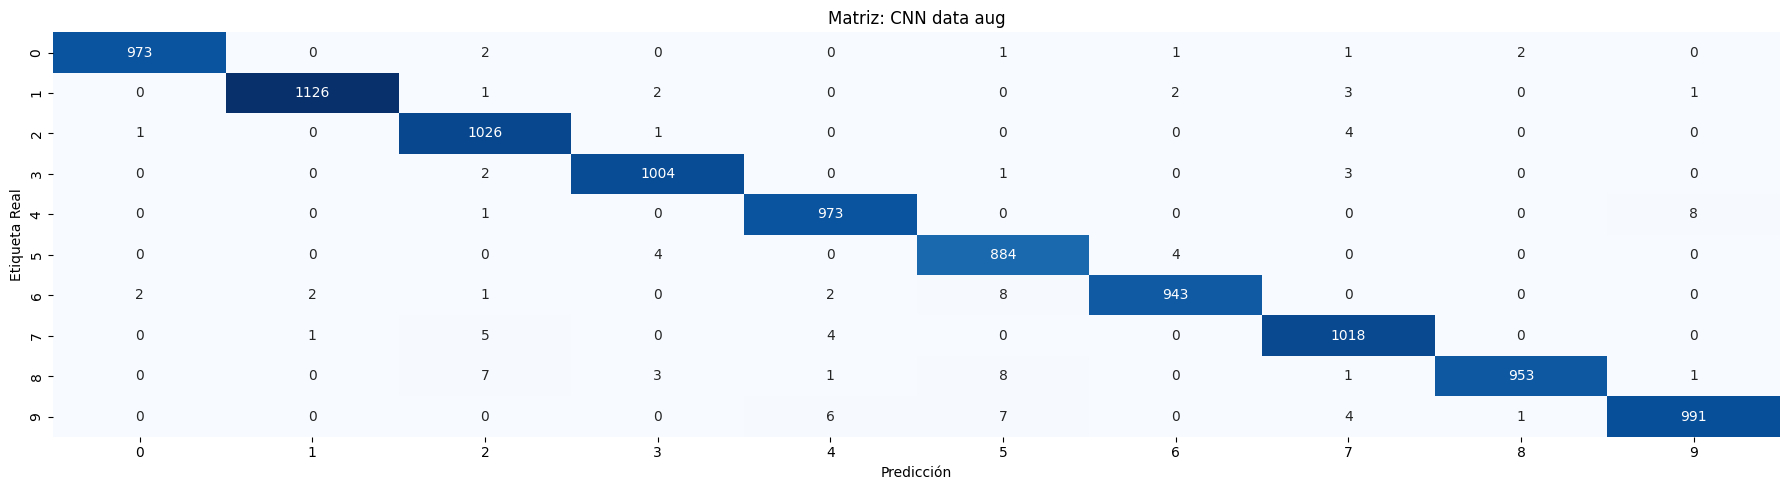

In [17]:
modelos = [model_cnn_data_aug]
nombres = ["CNN data aug"]

fig, axes = plt.subplots(1, 1, figsize=(18, 5))

# Define the labels for MNIST digits dynamically from y_train
mnist_labels = [str(label) for label in np.unique(y_train)]

for i, model in enumerate(modelos):
    # 1. Obtenemos el vector de probabilidades (3 columnas)
    y_pred_prob = model.predict(X_test, verbose=0)
    # 2. Nos quedamos con la clase de mayor probabilidad
    y_pred = np.argmax(y_pred_prob, axis=1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes, cbar=False,
                xticklabels=mnist_labels,
                yticklabels=mnist_labels)

    axes.set_title(f'Matriz: {nombres[i]}')
    axes.set_xlabel('Predicción')
    axes.set_ylabel('Etiqueta Real')

plt.tight_layout()
plt.show()

### Conclusión

Ambos modelos tienen una accuracy similar por lo que nos quedamos con el modelo básico (al ser más sencillo de entrenar).

## 9. Exportar el modelo

In [18]:
# Nuestro modelo tiene dos capas al inicio que debemos eliminar
# 1. Preprocesamiento
# 2. Data augmentation (no necesitamos que distorsione la imagen que pasamos)
modelo_para_exportar = tf.keras.Sequential(model_cnn_data_aug.layers[2:]) # Saltarse las capas de preprocesamiento

# Construir el modelo explícitamente con la forma de entrada esperada
# La capa Conv2D 'conv2d_10' que es la primera en este nuevo modelo,
# espera una entrada de 28x28x1 (después de las capas de preprocesamiento y data augmentation)
modelo_para_exportar.build(input_shape=(None, 28, 28, 1))

modelo_para_exportar.save('modelo_sin_capas_error.keras')

In [19]:
tfjs.converters.save_keras_model(modelo_para_exportar, 'modelo_cnn_data_aug_mnist_limpio')

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
